<a href="https://colab.research.google.com/github/late-cat/Sec_colab/blob/main/notebooks/01_model_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Customer Churn Optimization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## loading dataset

In [2]:
url = "https://raw.githubusercontent.com/late-cat/Sec_colab/main/data/Churn_Modelling.csv"
dataset = pd.read_csv(url)
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## dividing data set

In [3]:
X = dataset.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
Y = dataset['Exited']

In [4]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [5]:
Y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


## Feature engeneering

In [6]:
geography = pd.get_dummies(X['Geography'], drop_first=True)
gender = pd.get_dummies(X['Gender'], drop_first=True)

In [7]:
X = X.drop(['Geography', 'Gender'], axis=1)

In [8]:
X = pd.concat([X, geography, gender], axis=1)

In [9]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


## test train split

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

## fetaure scaling

In [11]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## handling imbalanced data (SMOTE)

In [12]:
smote = SMOTE(random_state=42)
X_train_sm, Y_train_sm = smote.fit_resample(X_train, Y_train)

In [13]:
Y_train_sm.value_counts()

,count
Exited,
1,6370
0,6370


## training base model & cross-validation

In [14]:
base_rf = RandomForestClassifier(random_state=42)
base_rf.fit(X_train_sm, Y_train_sm)

RandomForestClassifier(random_state=42)

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_cv = cross_val_score(base_rf, X_train_sm, Y_train_sm, cv=skf, scoring='f1')
print(f"Base CV F1: {base_cv.mean():.4f} ± {base_cv.std():.4f}")

Base CV F1: 0.8963 ± 0.0069


## hyperparameter tuning

In [16]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

In [17]:
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_sm, Y_train_sm)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='f1')

In [18]:
tuned_rf = random_search.best_estimator_
random_search.best_params_

{'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 20}

## deep error analysis & comparison

In [19]:
base_preds = base_rf.predict(X_test)
base_probs = base_rf.predict_proba(X_test)[:, 1]

tuned_preds = tuned_rf.predict(X_test)
tuned_probs = tuned_rf.predict_proba(X_test)[:, 1]

In [20]:
tuned_cv = cross_val_score(tuned_rf, X_train_sm, Y_train_sm, cv=skf, scoring='f1')
print(f"Tuned CV F1: {tuned_cv.mean():.4f} ± {tuned_cv.std():.4f}")

Tuned CV F1: 0.8956 ± 0.0074


In [21]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Base Model': [
        accuracy_score(Y_test, base_preds),
        precision_score(Y_test, base_preds),
        recall_score(Y_test, base_preds),
        f1_score(Y_test, base_preds),
        roc_auc_score(Y_test, base_probs)
    ],
    'Tuned Model': [
        accuracy_score(Y_test, tuned_preds),
        precision_score(Y_test, tuned_preds),
        recall_score(Y_test, tuned_preds),
        f1_score(Y_test, tuned_preds),
        roc_auc_score(Y_test, tuned_probs)
    ]
})
comparison

,Metric,Base Model,Tuned Model
0,Accuracy,0.842000,0.840000
1,Precision,0.615776,0.607407
2,Recall,0.594595,0.604423
3,F1-Score,0.605000,0.605911
4,ROC-AUC,0.847496,0.851376


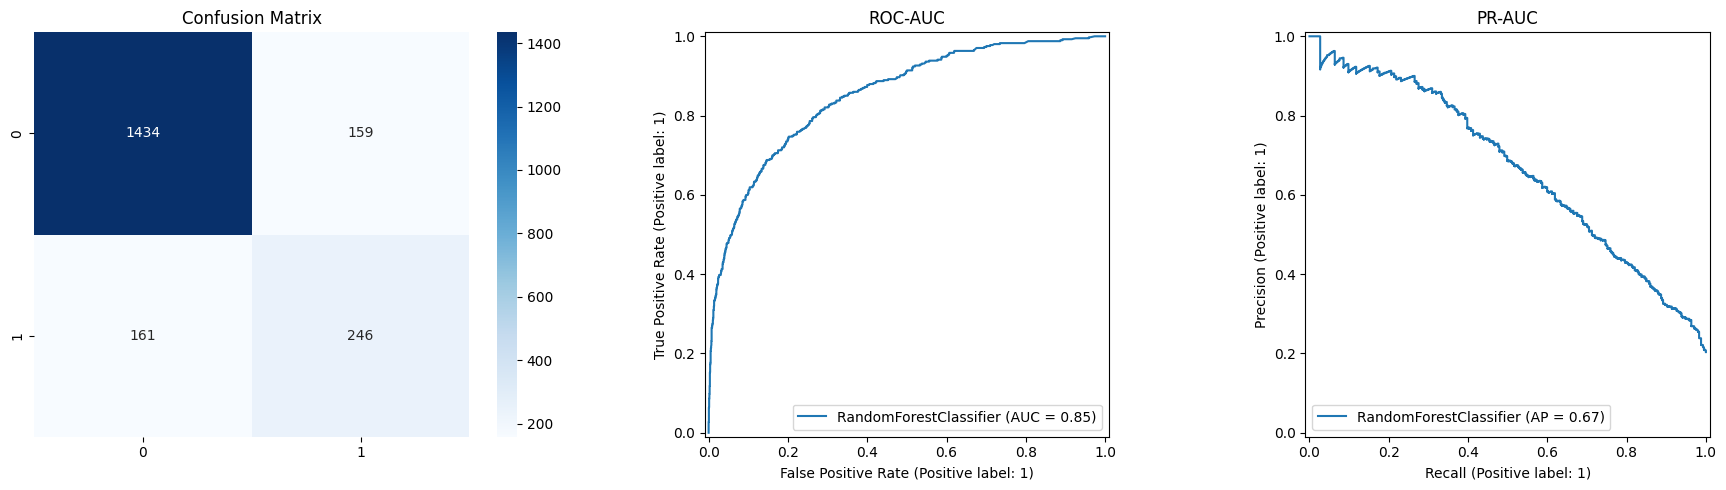

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(confusion_matrix(Y_test, tuned_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_estimator(tuned_rf, X_test, Y_test, ax=axes[1])
axes[1].set_title('ROC-AUC')

PrecisionRecallDisplay.from_estimator(tuned_rf, X_test, Y_test, ax=axes[2])
axes[2].set_title('PR-AUC')

plt.tight_layout()
plt.show()

## saving the model

In [23]:
save_dir = '../models/optimized models'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(tuned_rf, os.path.join(save_dir, 'final_model.joblib'))
joblib.dump(sc, os.path.join(save_dir, 'scaler.joblib'))

['../models/optimized models/scaler.joblib']